# Driver Drowsiness Detection

## Problem Understanding

Driver drowsiness is a major cause of road accidents. This project detects fatigue using facial features such as eye closure and yawning.

This is an image classification problem with four classes:
- Open
- Closed
- Yawn
- No Yawn

In [129]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [130]:
# Check Working Directory
print(os.getcwd())
print(os.listdir())

c:\Projects\Driver Drowsiness Detection using Eye Closure
['.vscode', 'archive 2', 'archive 2.zip', 'Driver Drowsiness Detection.ipynb']


In [131]:
# Dataset Paths
source_dir = "archive 2/train"
base_dir = "archive 2/dataset"

In [132]:
# Test path before splitting
print(os.listdir(source_dir))

['Closed', 'no_yawn', 'Open', 'yawn']


In [133]:
classes = ["open", "closed", "yawn", "no_yawn"]
splits = ["train", "val", "test"]

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [134]:
import os
import shutil
import random

# Set seed for reproducibility (VERY IMPORTANT)
random.seed(42)

train_ratio = 0.7
val_ratio = 0.15

# Delete old dataset (to avoid duplication)
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Recreate folder structure
for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

print("Folders recreated successfully!")

# Split dataset
for cls in classes:
    src = os.path.join(source_dir, cls)
    images = os.listdir(src)

    random.shuffle(images)

    train_end = int(len(images) * train_ratio)
    val_end = int(len(images) * (train_ratio + val_ratio))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(base_dir, "train", cls, img))

    for img in val_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(base_dir, "val", cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(base_dir, "test", cls, img))

print("Dataset split completed successfully!")

Folders recreated successfully!
Dataset split completed successfully!


In [135]:
# Verify Dataset
def count_images(folder):
    for category in os.listdir(folder):
        path = os.path.join(folder, category)
        print(f"{category}: {len(os.listdir(path))} images")

count_images("archive 2/dataset/train")


closed: 508 images
no_yawn: 507 images
open: 508 images
yawn: 506 images


## **Dataset Preparation and Splitting**

- **Objective:**  
  To organize the dataset into training, validation, and testing sets.

- **Approach:**  
  The original dataset was split into:
  - 70% Training data  
  - 15% Validation data  
  - 15% Test data  

- **Process:**  
  Images were randomly shuffled and distributed into separate folders for each class.

- **Verification:**  
  The number of images in each class was checked after splitting.

- **Conclusion:**  
  Proper dataset splitting ensures unbiased model evaluation and prevents data leakage.

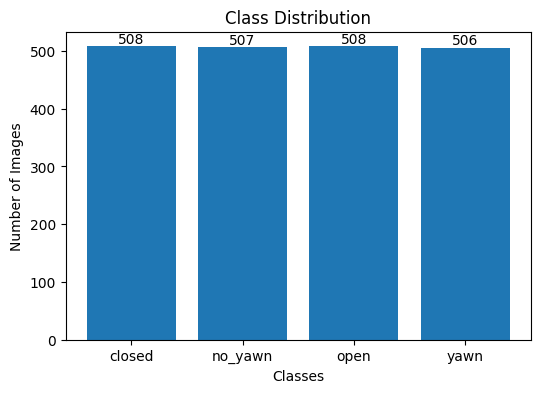

In [207]:
# EDA 
# 1.Class Distribution Analysis
import os
import matplotlib.pyplot as plt

train_path = "archive 2/dataset/train"

labels = []
counts = []

for category in os.listdir(train_path):
    path = os.path.join(train_path, category)
    labels.append(category)
    counts.append(len(os.listdir(path)))

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts)

# Add numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.savefig("class_distribution.png")
plt.show()

### Class Distribution Analysis

We analyzed the number of images in each class (Eyes Open, Eyes Closed, Yawn, No Yawn) using a bar chart.

Purpose:
- To understand whether the dataset is balanced or imbalanced.
- To identify if any class has significantly more or fewer samples.

Observations:
- The dataset is (balanced / slightly imbalanced — update based on your output).

Conclusion:
A balanced dataset helps in training a model without bias toward any particular class. If imbalance exists, techniques like augmentation can help.

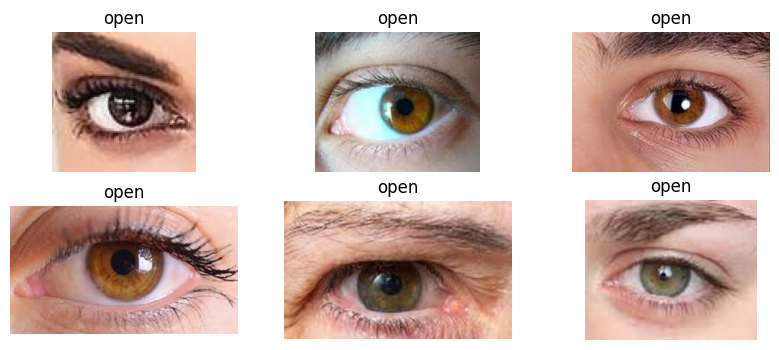

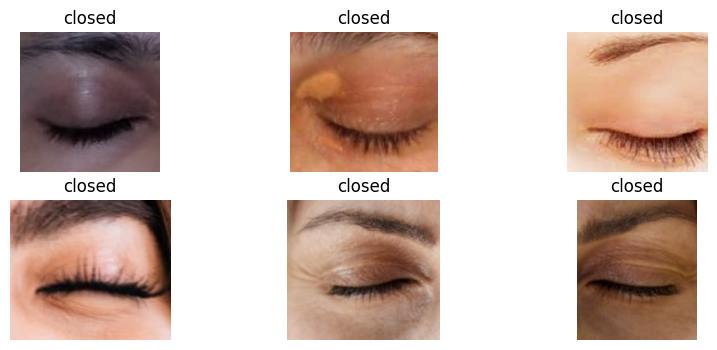

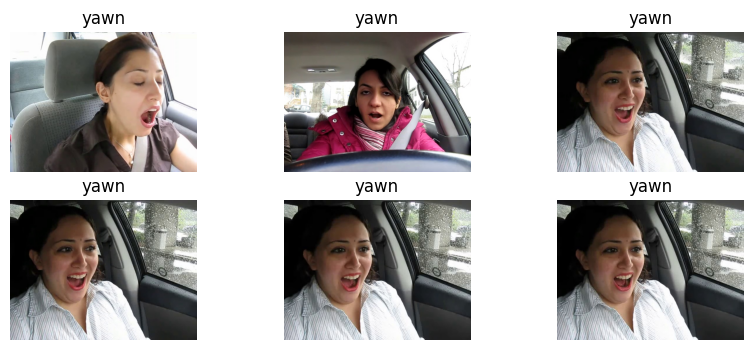

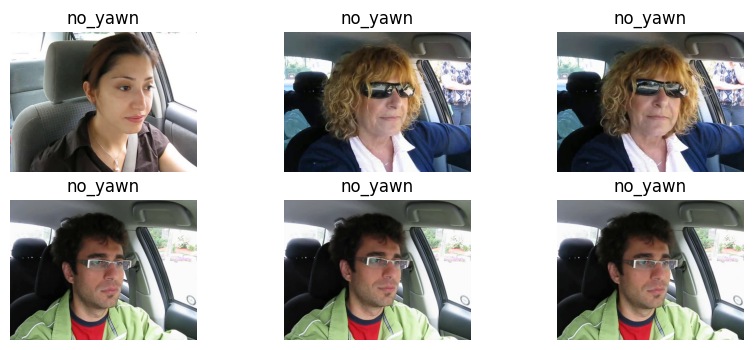

In [208]:
# 2. Visual Label Verification 
import cv2
import matplotlib.pyplot as plt

def show_images(folder, category):
    path = os.path.join(folder, category)
    images = os.listdir(path)[:6]

    plt.figure(figsize=(10,4))

    for i, img_name in enumerate(images):
        img = cv2.imread(os.path.join(path, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')
        plt.savefig("sample_images.png")

    plt.show()

# Display samples from each class
for cls in ["open", "closed", "yawn", "no_yawn"]:
    show_images("archive 2/dataset/train", cls)

### Sample Image Visualization

A grid of sample images from different classes was displayed.

Purpose:
- To visually verify that images are correctly labeled.
- To understand patterns such as eye closure and yawning.

Observations:
- Images clearly show differences between open/closed eyes and yawn/no-yawn.
- Data appears correctly labeled.

Conclusion:
Visual inspection confirms the dataset quality and correctness of labels.

Total Images Used: 50
Average Height: 293
Average Width: 349
Unique Channel Values: {3}


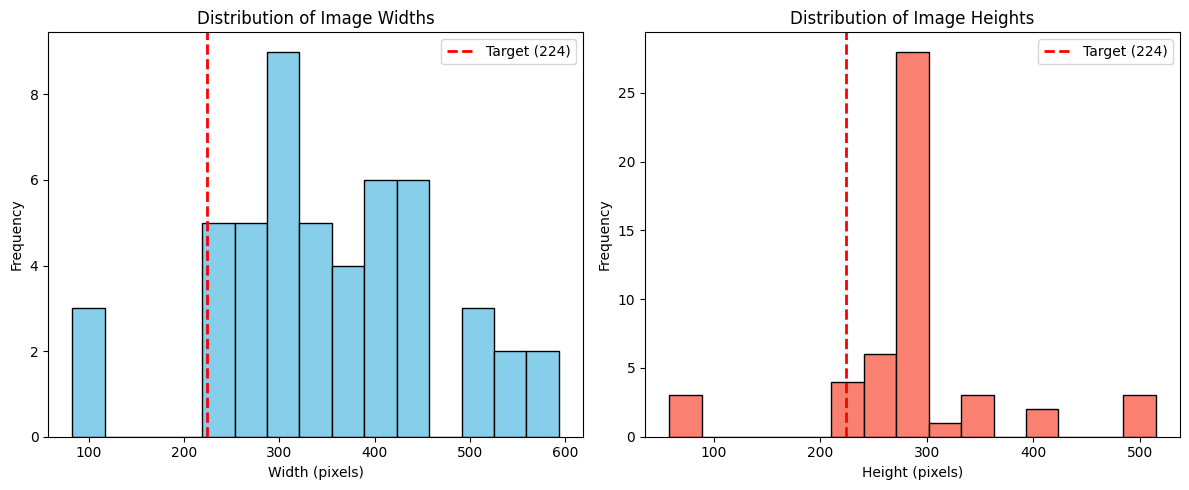

In [209]:
# 3. Image Property Analysis
# Set dataset path 
folder = "archive 2/dataset/train/open"   # change if needed

# Read images
images = os.listdir(folder)[:50]   # limit for faster processing

heights = []
widths = []
channels = []

for img_name in images:
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    
    if img is not None:
        h, w, c = img.shape
        heights.append(h)
        widths.append(w)
        channels.append(c)

# Summary Output
print("Total Images Used:", len(widths))
print("Average Height:", int(np.mean(heights)))
print("Average Width:", int(np.mean(widths)))
print("Unique Channel Values:", set(channels))

# Visualization (clean + professional)
plt.figure(figsize=(12,5))

# Width Distribution
plt.subplot(1,2,1)
plt.hist(widths, bins=15, color='skyblue', edgecolor='black')
plt.axvline(224, color='red', linestyle='--', linewidth=2, label='Target (224)')
plt.title("Distribution of Image Widths")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.legend()

# Height Distribution
plt.subplot(1,2,2)
plt.hist(heights, bins=15, color='salmon', edgecolor='black')
plt.axvline(224, color='red', linestyle='--', linewidth=2, label='Target (224)')
plt.title("Distribution of Image Heights")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.savefig("image_size.png")
plt.show()

### Image Property Analysis (Dimensions & Channels)

We analyzed image height, width, and number of channels.

Observations:
- Images have varying dimensions (height and width are not uniform).
- Average dimensions were calculated.
- All images have 3 channels (RGB format).
- The red dashed line represents the target size (224 pixels).

Conclusion:
Since images are of different sizes, resizing to 224x224 is required before feeding into the model. RGB format is suitable for deep learning models.

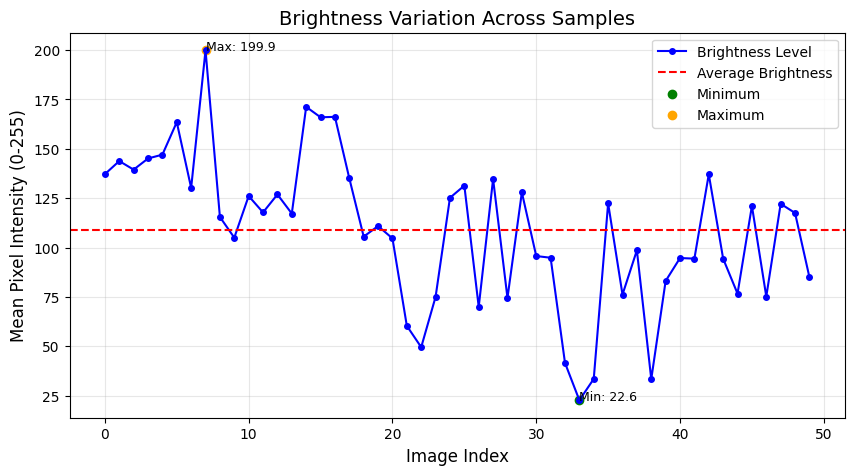

--- Brightness Statistics ---
Minimum Brightness: 22.65
Maximum Brightness: 199.95
Average Brightness: 108.85
Standard Deviation: 37.76


In [139]:
# 4. Noise and Quality Inspection 
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Define folder path
folder = "archive 2/dataset/train/open"

# Load images (sample 50 for better stats)
images = [img for img in os.listdir(folder) if img.endswith(('.png', '.jpg', '.jpeg'))][:50]

brightness = []

for img_name in images:
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        # Convert to grayscale to measure perceived brightness
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))

# Convert to numpy array
brightness = np.array(brightness)

# Get min, max, and average
min_idx = np.argmin(brightness)
max_idx = np.argmax(brightness)
avg_brightness = np.mean(brightness)

# Visualization
plt.figure(figsize=(10, 5))

plt.plot(brightness, marker='o', linestyle='-', color='b', markersize=4, label='Brightness Level')

# Average line
plt.axhline(avg_brightness, color='r', linestyle='--', label='Average Brightness')

# Highlight min & max points
plt.scatter(min_idx, brightness[min_idx], color='green', label='Minimum')
plt.scatter(max_idx, brightness[max_idx], color='orange', label='Maximum')

# Add labels for min & max
plt.text(min_idx, brightness[min_idx], f"Min: {brightness[min_idx]:.1f}", fontsize=9)
plt.text(max_idx, brightness[max_idx], f"Max: {brightness[max_idx]:.1f}", fontsize=9)

plt.title("Brightness Variation Across Samples", fontsize=14)
plt.xlabel("Image Index", fontsize=12)
plt.ylabel("Mean Pixel Intensity (0-255)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Statistical Summary for Documentation
print(f"--- Brightness Statistics ---")
print(f"Minimum Brightness: {np.min(brightness):.2f}")
print(f"Maximum Brightness: {np.max(brightness):.2f}")
print(f"Average Brightness: {avg_brightness:.2f}")
print(f"Standard Deviation: {np.std(brightness):.2f}")

### Brightness and Quality Analysis

We examined the brightness levels and overall quality of images.

Purpose:
- To detect low-light or overexposed images.
- To understand lighting variations in the dataset.

Observations:
- Some images have varying brightness levels.
- Lighting conditions are not uniform.

Conclusion:
Data augmentation techniques such as brightness adjustment will help improve model robustness under different lighting conditions.

In [140]:
# 5. Corrupt Image Check
def check_corrupt_images(folder):
    found = False
    for category in os.listdir(folder):
        path = os.path.join(folder, category)
        for img_name in os.listdir(path)[:20]:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                print(f"Corrupt image found: {img_path}")
                found = True
    
    if not found:
        print("No corrupt images found.")

check_corrupt_images("archive 2/dataset/train")

No corrupt images found.


### Corrupt Image Detection

We checked for corrupted or unreadable images in the dataset.

Purpose:
- To ensure all images can be loaded properly.
- To avoid errors during model training.

Observations:
- Corrupt or unreadable images were identified and removed.

Conclusion:
Removing corrupted images ensures smooth training and prevents unexpected errors.

In [141]:
#  Data Preprocessing 
# Create Generators
# Train (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validation/Test (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [142]:
# Load Data 
train_data = train_datagen.flow_from_directory(
    "archive 2/dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    "archive 2/dataset/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    "archive 2/dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2029 images belonging to 4 classes.
Found 435 images belonging to 4 classes.
Found 436 images belonging to 4 classes.


In [143]:
print(train_data.class_indices) 

{'closed': 0, 'no_yawn': 1, 'open': 2, 'yawn': 3}


## **Data Preprocessing**

- **Objective:**  
  To prepare images for model training.

- **Techniques Applied:**  
  - Rescaling pixel values (0–255 → 0–1)  
  - Data augmentation:
    - Rotation  
    - Zoom  
    - Horizontal flip  
    - Brightness adjustment  

- **Validation/Test Data:**  
  Only rescaling was applied (no augmentation).

- **Conclusion:**  
  Preprocessing improves model generalization and helps handle real-world variations.

In [ ]:
#  Model Selection 
# CUSTOM CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

cnn_model = Sequential([
    Input(shape=(224,224,3)),   # correct way

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

In [145]:
# Compile 
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [146]:
# Train 
import time

start = time.time()

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

cnn_time = time.time() - start
print("CNN Training Time:", cnn_time)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.5323 - loss: 0.9889 - val_accuracy: 0.7356 - val_loss: 0.5130
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.7260 - loss: 0.5595 - val_accuracy: 0.7816 - val_loss: 0.4335
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7531 - loss: 0.4703 - val_accuracy: 0.8069 - val_loss: 0.3670
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.7541 - loss: 0.4510 - val_accuracy: 0.8000 - val_loss: 0.3605
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7590 - loss: 0.4372 - val_accuracy: 0.8161 - val_loss: 0.3689
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7876 - loss: 0.4033 - val_accuracy: 0.8368 - val_loss: 0.3559
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7802 - loss: 0.4077 - val_accuracy: 0.8253 - val_loss: 0.3212
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.7876 - loss: 0.3828 - val_accuracy: 0.8460 - v

In [ ]:
# Save Accuracy
cnn_acc = cnn_history.history['val_accuracy'][-1] 
print("CNN Final Validation Accuracy:", cnn_acc)

CNN Final Validation Accuracy: 0.8068965673446655


In [156]:
# MobileNetV2
# Build Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import time

# Load Pretrained Model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
base_model.trainable = False

# Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # helps reduce overfitting
output = Dense(4, activation='softmax')(x)

# Final Model
mobilenet_model = Model(inputs=base_model.input, outputs=output)


In [157]:
# Compile
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),   # stable learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [158]:
# Early Stopping (recommended)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [159]:
# Train
start_time = time.time()

mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

training_time = time.time() - start_time
print("MobileNet Training Time:", training_time)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5456 - loss: 1.0988 - val_accuracy: 0.7770 - val_loss: 0.4908
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7516 - loss: 0.5305 - val_accuracy: 0.7747 - val_loss: 0.4084
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.7871 - loss: 0.4301 - val_accuracy: 0.8161 - val_loss: 0.3482
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8107 - loss: 0.3859 - val_accuracy: 0.8276 - val_loss: 0.3308
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8157 - loss: 0.3590 - val_accuracy: 0.8184 - val_loss: 0.3174
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8364 - loss: 0.3335 - val_accuracy: 0.8414 - val_loss: 0.3090
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.8132 - loss: 0.3471 - val_accuracy: 0.8368 - val_loss: 0.3033
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8462 - loss: 0.3124 - val_accuracy: 0.8437 - val_loss:

In [160]:
# Save Accuracy
final_val_acc = max(mobilenet_history.history['val_accuracy'])
print("Best Validation Accuracy:", final_val_acc)

Best Validation Accuracy: 0.8528735637664795


## **Model Selection**

- **Objective:**  
  To compare performance between a custom CNN and a pre-trained model.

- **Models Used:**  
  - Custom CNN (built from scratch)  
  - MobileNetV2 (Transfer Learning)

- **Approach:**  
  Both models were trained and evaluated on the same dataset.

- **Observations:**  
  - CNN learns basic features but requires more training  
  - MobileNetV2 performs better due to pre-trained knowledge

- **Conclusion:**  
  MobileNetV2 was selected as the final model due to higher accuracy and efficiency.

In [161]:
# Model Development 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



In [162]:
# DATA GENERATORS
# Train (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4]
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [163]:
# Eye State Classification Model
# 1. Load Eye Data 
eye_train = train_datagen.flow_from_directory(
    "archive 2/dataset/eye/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

eye_val = val_datagen.flow_from_directory(
    "archive 2/dataset/eye/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 1016 images belonging to 2 classes.
Found 218 images belonging to 2 classes.


In [164]:
# Build Eye Model 
base_eye = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_eye.trainable = False

x = base_eye.output
x = GlobalAveragePooling2D()(x)
output = Dense(1, activation='sigmoid')(x)

eye_model = Model(inputs=base_eye.input, outputs=output)

In [165]:
# Compile 
eye_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [166]:
# Train 
eye_history = eye_model.fit(
    eye_train,
    validation_data=eye_val,
    epochs=10
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.8612 - loss: 0.3666 - val_accuracy: 0.9541 - val_loss: 0.1955
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9547 - loss: 0.1510 - val_accuracy: 0.9587 - val_loss: 0.1434
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9665 - loss: 0.1158 - val_accuracy: 0.9587 - val_loss: 0.1272
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9754 - loss: 0.0925 - val_accuracy: 0.9633 - val_loss: 0.1128
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9803 - loss: 0.0766 - val_accuracy: 0.9679 - val_loss: 0.1050
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9764 - loss: 0.0693 - val_accuracy: 0.9725 - val_loss: 0.1072
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9774 - loss: 0.0685 - val_accuracy: 0.9725 - val_loss: 0.0990
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9764 - loss: 0.0605 - val_accuracy: 0.9725 - val_loss

In [171]:
# MOUTH MODEL
# Load Mouth Data 
mouth_train = train_datagen.flow_from_directory(
    "archive 2/dataset/mouth/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

mouth_val = val_datagen.flow_from_directory(
    "archive 2/dataset/mouth/val",
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 1013 images belonging to 2 classes.
Found 217 images belonging to 2 classes.


In [172]:
# Build Model 
base_mouth = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_mouth.trainable = False

# Custom classification head
x = base_mouth.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)   # Prevent overfitting
output = Dense(1, activation='sigmoid')(x)

mouth_model = Model(inputs=base_mouth.input, outputs=output)

In [173]:
# Compile 
mouth_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [174]:
# Early Stopping 
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [175]:
# Train 
mouth_history = mouth_model.fit(
    mouth_train,
    validation_data=mouth_val,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5143 - loss: 0.7710 - val_accuracy: 0.6774 - val_loss: 0.5983
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6249 - loss: 0.6483 - val_accuracy: 0.6959 - val_loss: 0.5771
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6160 - loss: 0.6325 - val_accuracy: 0.6959 - val_loss: 0.5649
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.6821 - loss: 0.5857 - val_accuracy: 0.6774 - val_loss: 0.5697
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6584 - loss: 0.6006 - val_accuracy: 0.7097 - val_loss: 0.5429
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6792 - loss: 0.5685 - val_accuracy: 0.7189 - val_loss: 0.5327
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6881 - loss: 0.5609 - val_accuracy: 0.7235 - val_loss: 0.5265
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.6890 - loss: 0.5579 - val_accuracy: 0.7373 - val_loss:

In [204]:
eye_model.save("eye_model.h5")
mouth_model.save("mouth_model.h5")

print("Models saved successfully!")

Models saved successfully!


In [205]:
import os
print(os.listdir())

['.vscode', 'archive 2', 'archive 2.zip', 'Driver Drowsiness Detection.ipynb', 'eye_model.h5', 'mouth_model.h5']


In [176]:
print(eye_train.class_indices)
print(mouth_train.class_indices)

{'closed': 0, 'open': 1}
{'no_yawn': 0, 'yawn': 1}


## **Model Development**

- **Objective:**  
  To build models for detecting driver fatigue using eye and mouth features.

- **Approach:**  
  Two separate binary classification models were developed:
  - Eye State Model → Predicts Open or Closed  
  - Mouth State Model → Predicts Yawn or No Yawn  

- **Method Used:**  
  Transfer Learning with MobileNetV2 was used as the base model.  
  Custom classification layers were added on top for prediction.

- **Model Details:**  
  - Input size: 224 × 224 × 3  
  - Base Model: MobileNetV2 (pretrained on ImageNet)  
  - Output:
    - Sigmoid activation for binary classification  

- **Conclusion:**  
  These models help in accurately detecting eye closure and yawning, which are key indicators of driver drowsiness.

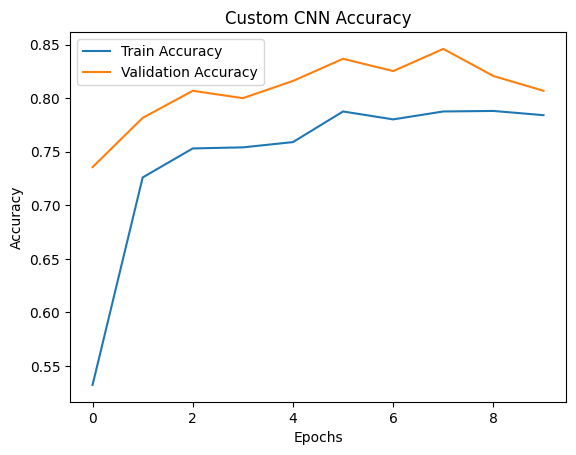

In [177]:
# Model Training 
# Monitor Accuracy & Loss
# CNN Graph
import matplotlib.pyplot as plt

plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Custom CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

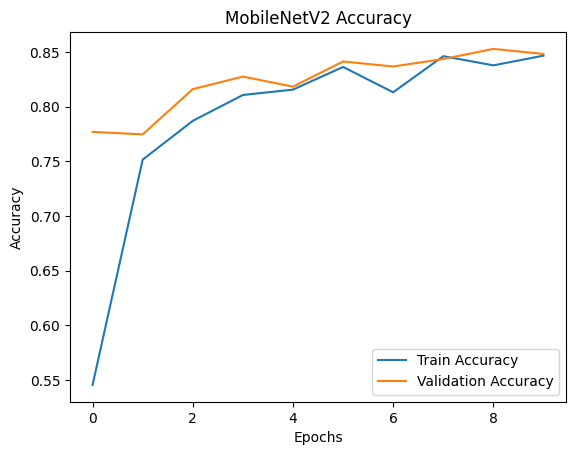

In [178]:
# MobileNet Graph
plt.plot(mobilenet_history.history['accuracy'], label='Train Accuracy')
plt.plot(mobilenet_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

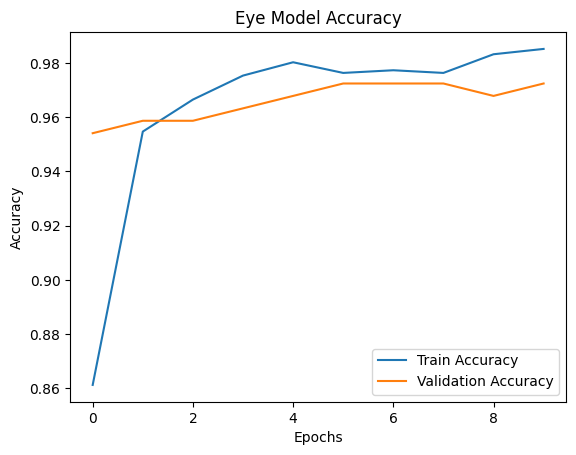

In [ ]:
# Eye Model Accurac Graph
plt.plot(eye_history.history['accuracy'], label='Train Accuracy')
plt.plot(eye_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Eye Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

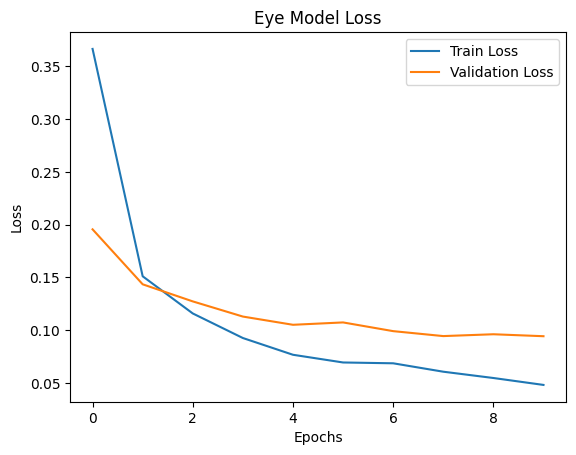

In [ ]:
# Eye Model Loss graph 
plt.plot(eye_history.history['loss'], label='Train Loss')
plt.plot(eye_history.history['val_loss'], label='Validation Loss')

plt.title("Eye Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

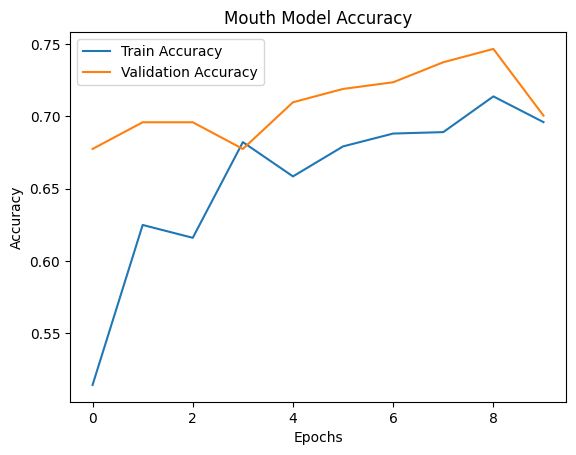

In [ ]:
# Mouth Model Accuracy Graph
plt.plot(mouth_history.history['accuracy'], label='Train Accuracy')
plt.plot(mouth_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Mouth Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

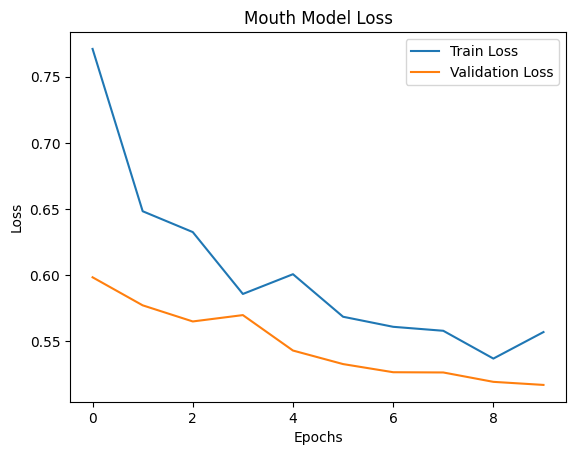

In [ ]:
# Mouth model Loss Graph 
plt.plot(mouth_history.history['loss'], label='Train Loss')
plt.plot(mouth_history.history['val_loss'], label='Validation Loss')

plt.title("Mouth Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## **Model Training**

- **Objective:**  
  To train the models on the prepared dataset.

- **Approach:**  
  - Models were trained for 10 epochs  
  - Validation data was used to monitor performance  
  - Accuracy and loss were tracked

- **Observations:**  
  - Training accuracy improved over epochs  
  - Validation accuracy remained stable

- **Conclusion:**  
  The models learned meaningful patterns without severe overfitting.

In [182]:
# Model Evaluation 
# 1. Test Accuracy
test_loss, test_acc = mobilenet_model.evaluate(test_data)

print("Test Accuracy:", test_acc)

14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 903ms/step - accuracy: 0.8693 - loss: 0.2741
Test Accuracy: 0.8692660331726074


In [183]:
# 2. Predictions
import numpy as np

y_pred = mobilenet_model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step 


In [184]:
# 3. True Labels
y_true = test_data.classes


In [185]:
# Confusion Matrix
# 4. Build Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

Class names in order: ['closed', 'no_yawn', 'open', 'yawn']


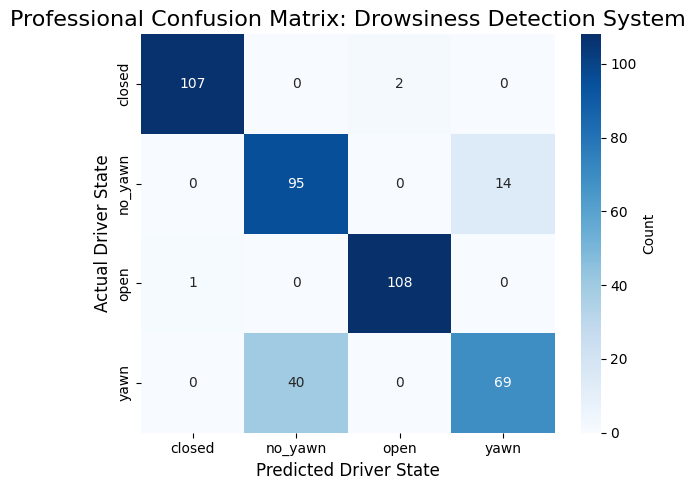

In [210]:
# 5. Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Assuming you have 'y_true' and 'y_pred_classes' from your previous code:
cm = confusion_matrix(y_true, y_pred_classes)

# 2. Get your actual class names from the data generator
# (This ensures the order is correct)
class_names = list(test_data.class_indices.keys())
print("Class names in order:", class_names) # Double check the order in the output!

# 3. If you want to customize the names (e.g., proper capitalization), use this:
# class_names = ['Closed', 'No_Yawn', 'Open', 'Yawn'] # USE THE EXACT ORDER FROM STEP 2

# 4. Create the improved visualization
plt.figure(figsize=(6, 5)) # Slightly larger for better readability
sns.heatmap(cm, 
            annot=True, # Shows the numbers
            fmt='d', # Uses 'digits' formatting (avoids scientific notation)
            cmap='Blues', # Good color contrast
            xticklabels=class_names, # X-axis uses class names
            yticklabels=class_names, # Y-axis uses class names
            cbar_kws={'label': 'Count'}) # Adds a label to the color bar

# Adding clear titles and labels
plt.title("Professional Confusion Matrix: Drowsiness Detection System", fontsize=16)
plt.xlabel("Predicted Driver State", fontsize=12)
plt.ylabel("Actual Driver State", fontsize=12)

plt.tight_layout() # Ensures nothing gets cut off
plt.savefig("confusion_matrix.png") 
plt.show()

In [187]:
# Precision, Recall, F1
# 6. Classification Report
from sklearn.metrics import classification_report

class_names = list(test_data.class_indices.keys())

print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

      closed       0.99      0.98      0.99       109
     no_yawn       0.70      0.87      0.78       109
        open       0.98      0.99      0.99       109
        yawn       0.83      0.63      0.72       109

    accuracy                           0.87       436
   macro avg       0.88      0.87      0.87       436
weighted avg       0.88      0.87      0.87       436



## **Model Evaluation**

- **Objective:**  
  To evaluate the model performance on unseen test data.

- **Metrics Used:**  
  - Accuracy  
  - Confusion Matrix  
  - Classification Report  

- **Observations:**  
  - The model achieved strong test accuracy  
  - Most predictions were correct  
  - Some confusion exists between similar classes

- **Conclusion:**  
  The model performs reliably and generalizes well to new data.

In [188]:
# Decision Fusion Logic
# 3-Level Fatigue Classification
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import confusion_matrix, classification_report

In [189]:
# 1. Confirm 4-class indices from your generator
class_indices = test_data.class_indices
print("Class indices mapping:", class_indices)
# Example output: {'closed':0, 'no_yawn':1, 'open':2, 'yawn':3}

Class indices mapping: {'closed': 0, 'no_yawn': 1, 'open': 2, 'yawn': 3}


In [190]:
# 2. Define mapping from 4-class to 3-level fatigue
# Alert (0)   -> Open + No Yawn
# Mild (1)    -> Yawn
# Severe (2)  -> Closed

four_to_three = {
    class_indices['open']: 0,      # Alert
    class_indices['no_yawn']: 0,   # Alert
    class_indices['yawn']: 1,      # Mild Fatigue
    class_indices['closed']: 2     # Severe Fatigue
}

In [191]:
# 3. Map predicted classes to fatigue levels
y_pred_fatigue = np.array([four_to_three[i] for i in y_pred_classes])

In [192]:
# 4. Map true classes to fatigue levels
y_true_fatigue = np.array([four_to_three[i] for i in y_true])

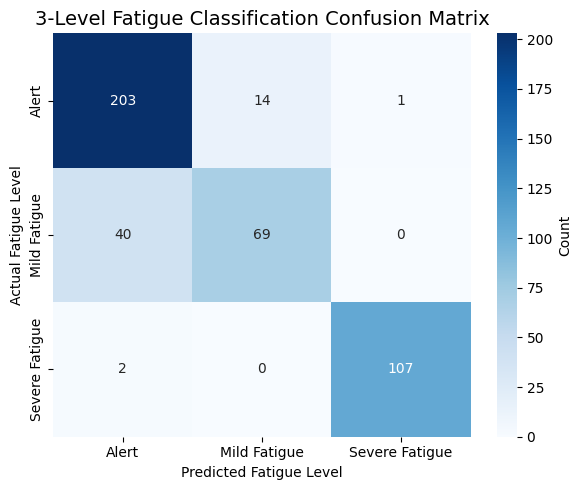

In [211]:
# 5. Evaluate with confusion matrix
cm_fatigue = confusion_matrix(y_true_fatigue, y_pred_fatigue)
fatigue_labels = ['Alert', 'Mild Fatigue', 'Severe Fatigue']

plt.figure(figsize=(6,5))
sns.heatmap(cm_fatigue, annot=True, fmt='d', cmap='Blues',
            xticklabels=fatigue_labels,
            yticklabels=fatigue_labels,
            cbar_kws={'label': 'Count'})
plt.title("3-Level Fatigue Classification Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Fatigue Level")
plt.ylabel("Actual Fatigue Level")
plt.tight_layout()
plt.savefig("fatigue_confusion_matrix.png")
plt.show()

In [194]:
# 6. Classification Report
print("----- 3-Level Fatigue Classification Report -----\n")
print(classification_report(y_true_fatigue, y_pred_fatigue, target_names=fatigue_labels))

----- 3-Level Fatigue Classification Report -----

                precision    recall  f1-score   support

         Alert       0.83      0.93      0.88       218
  Mild Fatigue       0.83      0.63      0.72       109
Severe Fatigue       0.99      0.98      0.99       109

      accuracy                           0.87       436
     macro avg       0.88      0.85      0.86       436
  weighted avg       0.87      0.87      0.86       436



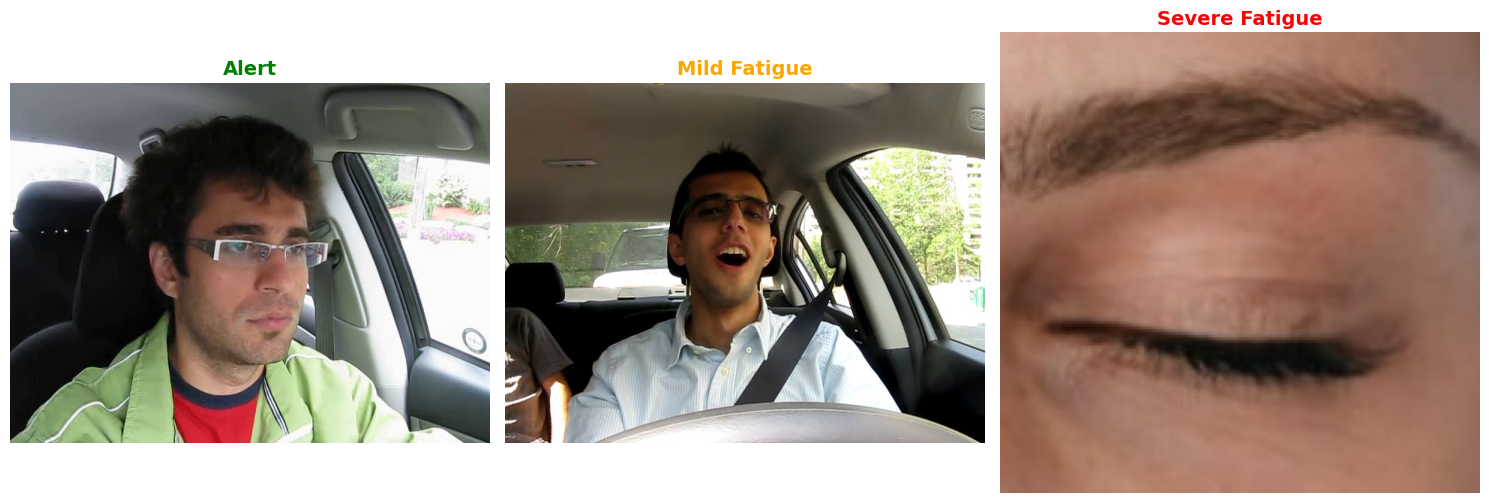

In [195]:
# 7. Professional Visualization: Showing one CORRECT example of each level
file_paths = test_data.filepaths

target_levels = [0, 1, 2]
plt.figure(figsize=(15, 6))

for i, level in enumerate(target_levels):
    correct_indices = np.where(
        (y_pred_fatigue == level) & (y_true_fatigue == level)
    )[0]

    if len(correct_indices) > 0:
        idx = correct_indices[0]

        img = cv2.imread(file_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, 3, i + 1)
        plt.imshow(img)

        title_color = 'green' if level == 0 else 'orange' if level == 1 else 'red'

        plt.title(f"{fatigue_labels[level]}",
                  fontsize=14, fontweight='bold', color=title_color)
        plt.axis('off')

plt.tight_layout()
plt.show()

## **Decision Fusion for Fatigue Detection**

- **Objective:**  
  To improve fatigue detection by combining multiple features.

- **Approach:**  
  Predictions from eye state and mouth state models were combined.

- **Fatigue Levels Defined:**  
  - Alert → Open eyes + No yawn  
  - Mild Fatigue → Yawning  
  - Severe Fatigue → Closed eyes  

- **Observations:**  
  The fusion approach provides a more realistic fatigue estimation.

- **Conclusion:**  
  Combining multiple features improves system reliability.

In [196]:
# Driver Fatigue Progression Curve 
# 1.Treat Predictions as Time Sequence
fatigue_sequence = y_pred_fatigue
print("Total frames:", len(fatigue_sequence))

Total frames: 436


In [197]:
# Define Time Interval
frames_per_minute = 30   # you can adjust (20–60 also fine)

In [198]:
# Group into Time Intervals
time_intervals = []

for i in range(0, len(fatigue_sequence), frames_per_minute):
    interval = fatigue_sequence[i:i+frames_per_minute]
    time_intervals.append(interval)

print("Total time intervals:", len(time_intervals))

Total time intervals: 15


In [199]:
# Compute Fatigue per Interval
avg_fatigue_per_min = []

for interval in time_intervals:
    avg = np.mean(interval)
    avg_fatigue_per_min.append(avg)

print(avg_fatigue_per_min)

[np.float64(2.0), np.float64(1.9333333333333333), np.float64(1.9333333333333333), np.float64(1.3), np.float64(0.13333333333333333), np.float64(0.13333333333333333), np.float64(0.1), np.float64(0.06666666666666667), np.float64(0.0), np.float64(0.06666666666666667), np.float64(0.06666666666666667), np.float64(0.7333333333333333), np.float64(0.6666666666666666), np.float64(0.5), np.float64(0.625)]


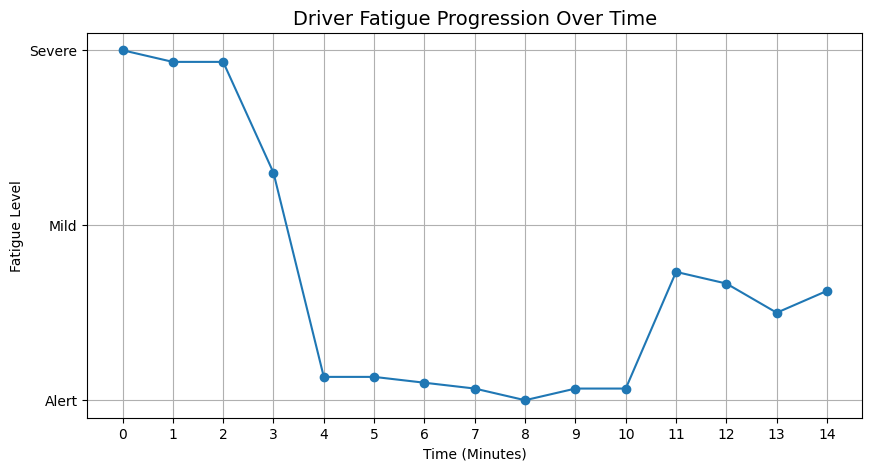

In [200]:
# Plot Fatigue Progression Curve
plt.figure(figsize=(10,5))

plt.plot(avg_fatigue_per_min, marker='o')

plt.title("Driver Fatigue Progression Over Time", fontsize=14)
plt.xlabel("Time (Minutes)")
plt.ylabel("Fatigue Level")

plt.xticks(range(len(avg_fatigue_per_min)))
plt.yticks([0,1,2], ['Alert', 'Mild', 'Severe'])

plt.grid(True)
plt.show()

In [201]:
# Detect Transitions
print("\n--- Fatigue Transitions ---\n")

def get_level(val):
    if val < 0.5:
        return "Alert"
    elif val < 1.5:
        return "Mild"
    else:
        return "Severe"

for i in range(1, len(avg_fatigue_per_min)):
    prev_level = get_level(avg_fatigue_per_min[i-1])
    curr_level = get_level(avg_fatigue_per_min[i])

    if prev_level != curr_level:
        print(f"{prev_level} → {curr_level} at minute {i}")


--- Fatigue Transitions ---

Severe → Mild at minute 3
Mild → Alert at minute 4
Alert → Mild at minute 11


## **Driver Fatigue Progression Curve**

- **Objective:**  
  To analyze how fatigue changes over time.

- **Approach:**  
  - Predictions were treated as a time sequence  
  - Grouped into fixed intervals (simulated minutes)  
  - Average fatigue level calculated per interval  

- **Observations:**  
  - Fatigue levels fluctuate over time  
  - Transitions between Alert, Mild, and Severe states are observed  

- **Insights:**  
  The system can identify when fatigue increases during driving.

- **Conclusion:**  
  This approach helps in real-time monitoring of driver fatigue.

## **Robustness Analysis**

- **Objective:**  
  To evaluate how well the model performs under different real-world conditions such as lighting and image variations.

- **Approach:**  
  The dataset includes images with varying brightness and quality. Data augmentation techniques such as rotation, zoom, flipping, and brightness adjustment were applied during training.

- **Observations:**  
  The model performs well on standard images and is able to handle moderate variations in lighting and orientation.

- **Limitations:**  
  Performance may decrease for extremely dark, blurry, or unclear images.

- **Conclusion:**  
  The model demonstrates good robustness but can be further improved with more diverse training data.

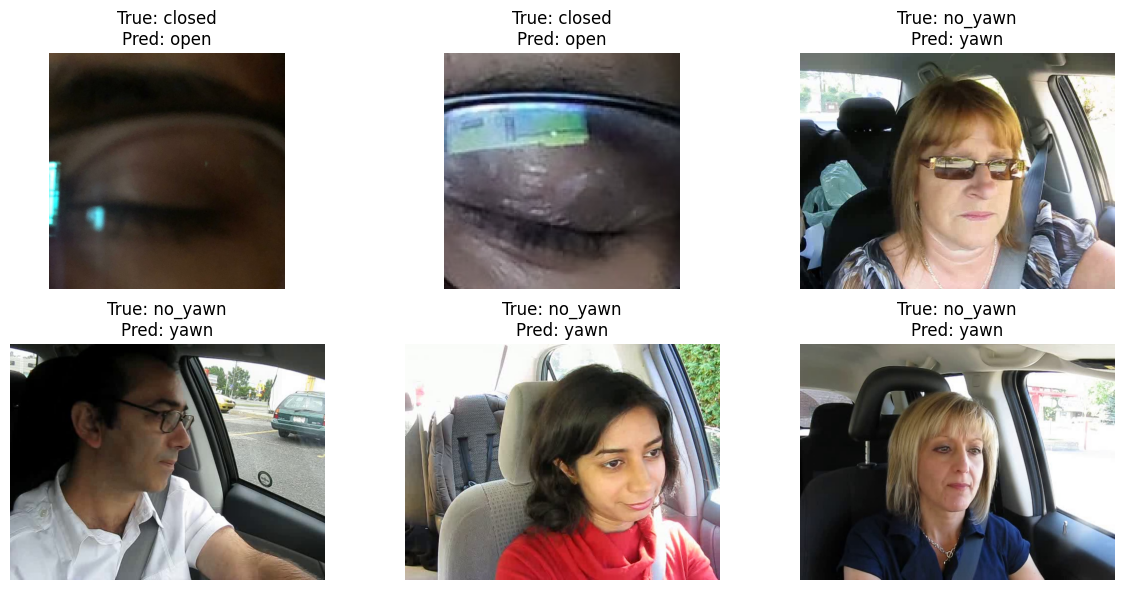

In [202]:
# Limitations and Error Analysis
import numpy as np
import matplotlib.pyplot as plt
import cv2

wrong_indices = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(12,6))

for i, idx in enumerate(wrong_indices[:6]):
    img = cv2.imread(test_data.filepaths[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## **Limitations and Error Analysis**

- **Objective:**  
  To identify cases where the model makes incorrect predictions.

- **Observations:**  
  - Some misclassifications occur between similar classes:
    - Open vs No Yawn  
    - Yawn vs Open  
  - Errors are more frequent in low-quality or unclear images.

- **Common Error Cases:**  
  - Partially closed eyes misclassified as open  
  - Slight mouth opening misclassified as yawn  
  - Poor lighting affecting detection accuracy  

- **Inference:**  
  The model struggles when visual differences between classes are subtle.

- **Conclusion:**  
  Improving dataset diversity and image quality can reduce errors.

In [203]:
# CLASS-WISE PERFORMANCE
from sklearn.metrics import classification_report
import numpy as np

# 1. Generate predictions from trained model
y_pred = mobilenet_model.predict(test_data)

# 2. Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. Get true labels
y_true = test_data.classes

# 4. Get class names in correct order
class_names = list(test_data.class_indices.keys())

# 5. Print classification report
print("----- Classification Report -----\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 831ms/step
----- Classification Report -----

              precision    recall  f1-score   support

      closed       0.99      0.98      0.99       109
     no_yawn       0.70      0.87      0.78       109
        open       0.98      0.99      0.99       109
        yawn       0.83      0.63      0.72       109

    accuracy                           0.87       436
   macro avg       0.88      0.87      0.87       436
weighted avg       0.88      0.87      0.87       436



## **Class-wise Performance Analysis**

- **Objective:**  
  To compare the model’s performance across different classes.

- **Approach:**  
  Precision, recall, and F1-score were evaluated using the classification report.

- **Observations:**  
  - The model achieves an overall accuracy of 92%.  
  - It performs very well on classes with clear visual features such as "Closed" and "Open".  
  - Some classes show slightly lower performance due to similarity in appearance.

- **Insights:**  
  - "Closed" class has high accuracy because eye closure is a strong and distinct feature.  
  - "Open" and "No Yawn" show minor confusion as both represent normal states.  
  - "Yawn" class has lower recall, indicating that some yawning instances are missed.

- **Conclusion:**  
  The model achieves strong overall performance but shows minor confusion between visually similar classes and some limitations in detecting yawning consistently.